In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing steps for the training data.
* Load the data and clean it. Remove duplicate values and null values.
* Statistical information about the data.

In [12]:
data=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/train.csv')
data.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [13]:
data.shape

(690088, 15)

In [14]:
def checking_null_values(data):
    sum_null =data.isna().sum()
    duplicate=data.duplicated().sum()
    print(f'\n The data contains {sum_null}')
    print(f'The data contains {duplicate}')
checking_null_values(data)


 The data contains id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64
The data contains 0


In [15]:
# Let's see a lot of null values in the data, we should fix it 
"""
First, I separated the numerical columns and categorical columns
I understand the first two columns are integers, and they are not null values
Instead, we take float values and 

"""
# Separate the numerical and categorical values

numerical=data.select_dtypes(include='float')
categorical=data.select_dtypes(include='object').columns

# Write two functions to fill null values 
def fill_numerical_values(data,columns):
    for col in columns:
        data[col]=data[col].fillna(data[col].mean())
    return data
data=fill_numerical_values(data,numerical)
def fill_categorical_values(data,columns):
    for col in columns:
        data[col]=data[col].fillna(data[col].mode()[0])
    return data
data=fill_categorical_values(data,categorical)

# The data now has zero null values
data.isna().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

# Load the test data and do preprocessing steps.
* Load the data and remove the null values and duplicate values so we do the same steps as the training data.

In [16]:
# Load the test data and apply the above cleaning processes
test_data=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/test.csv')
# drop the id columns for the 
test=test_data.drop(['id'],axis=1)
test_numerical=test.select_dtypes(include='float')
test_categorical=test_data.select_dtypes(include='object').columns
test=fill_numerical_values(test,test_numerical)
test=fill_categorical_values(test,test_categorical)
test.isna().sum()

sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [17]:
data.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000,690088.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.146529,8.128577,2.456669,333.958474,3889.578754,14.668292,0.501891
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.300000,69.500000,21.380000,2068.000000,5460.000000,29.300000,1.870000
50%,345043.50000,6.992597,75.096504,22.984925,2226.084931,8697.000000,39.200000,2.188542
75%,517565.25000,7.680000,80.600000,24.630000,2438.000000,12089.000000,49.300000,2.470000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


# Explore Data Analysis

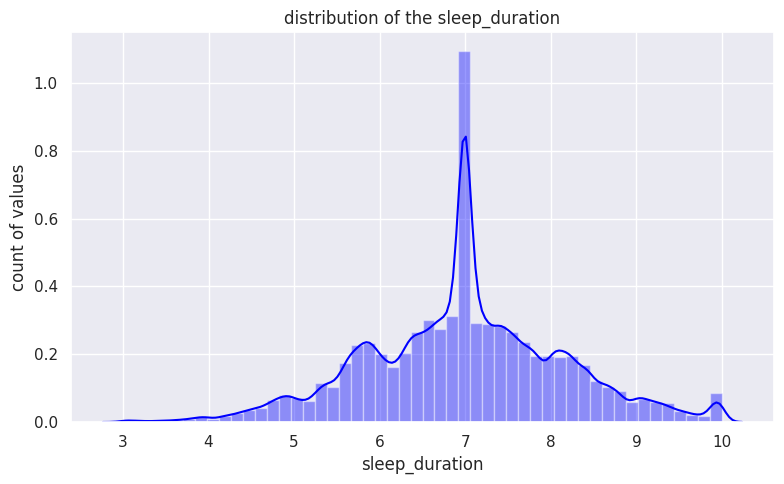

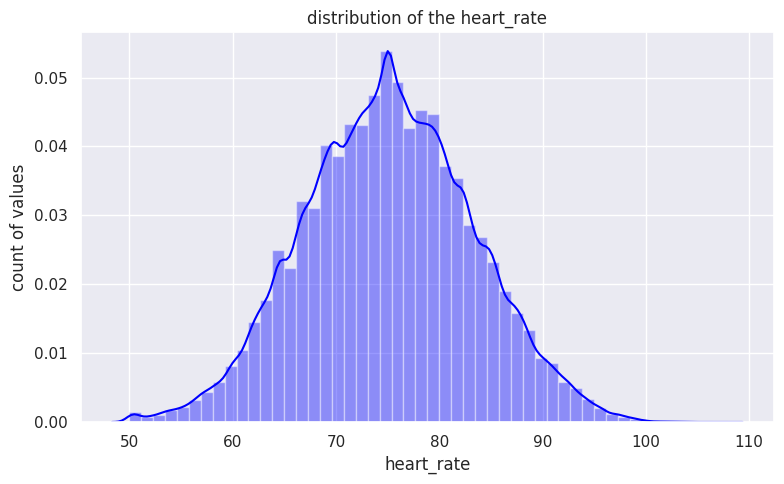

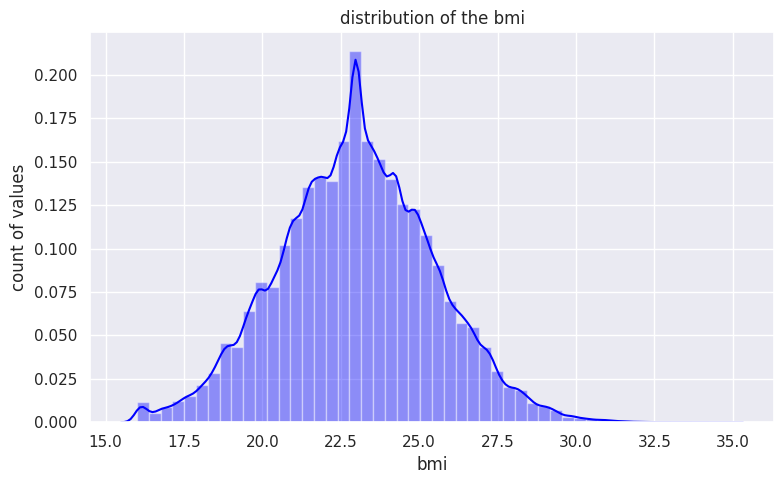

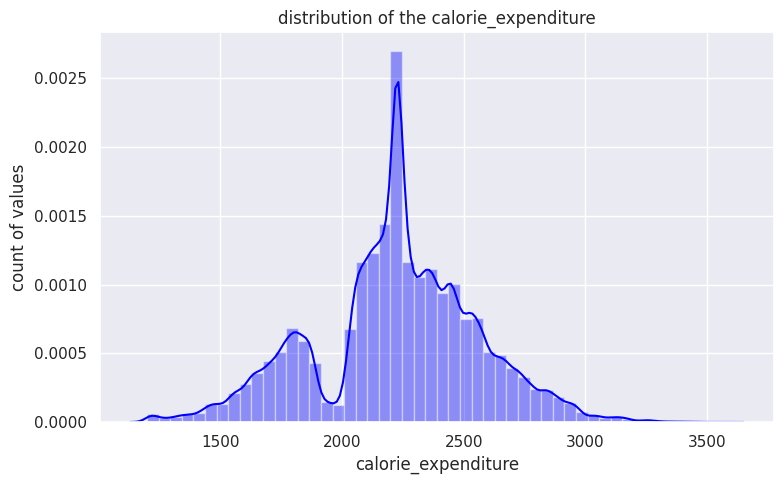

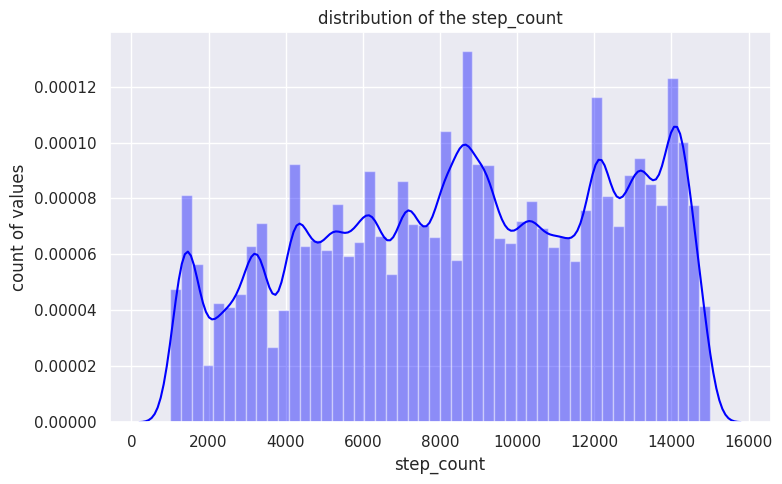

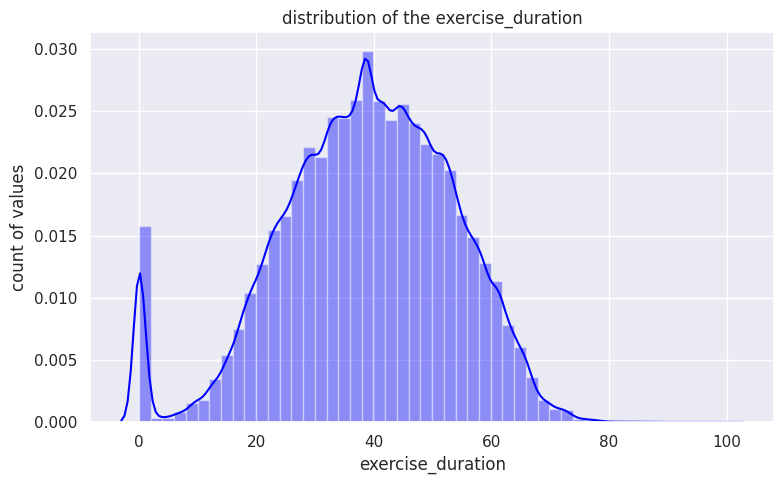

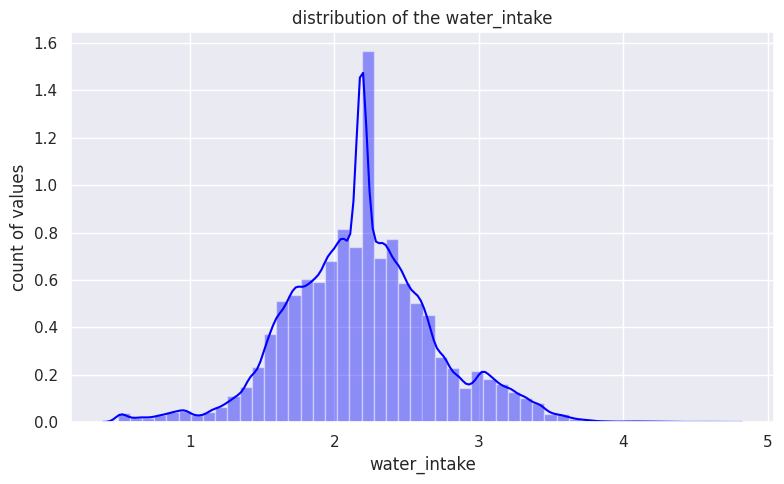

In [18]:
# Distribution of the numerical values
def distribution_numerical(data,col):
    plt.figure(figsize=(8,5))
    sns.set_theme(style='darkgrid')
    sns.distplot(
        data[col],
        kde=True,
        color='blue'
    )
    plt.title(f'distribution of the {col}')
    plt.xlabel(f'{col}')
    plt.ylabel('count of values')
    plt.tight_layout()
    plt.show()
numerical=data.select_dtypes(include='float').columns
for col in numerical:
    distribution_numerical(data,col)

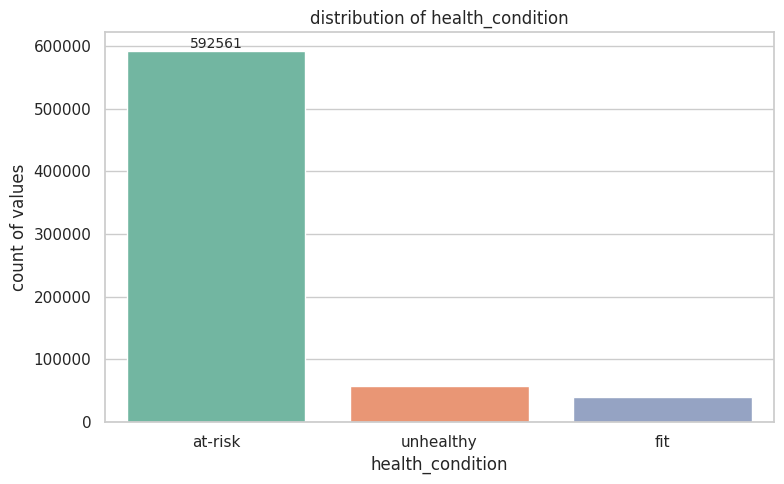

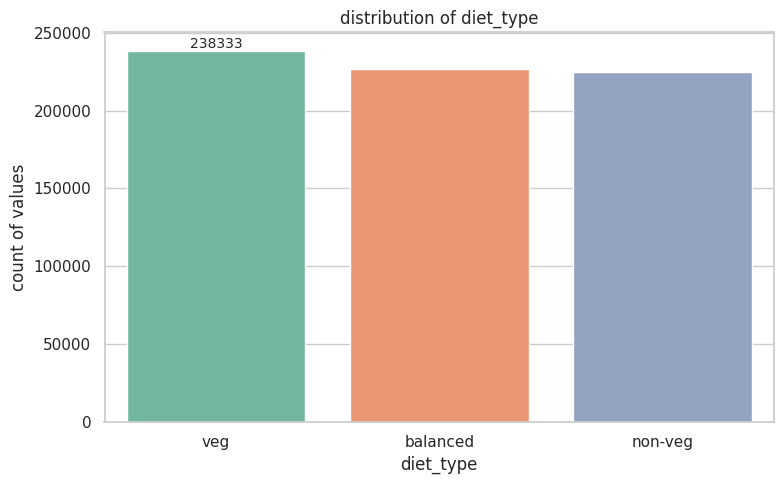

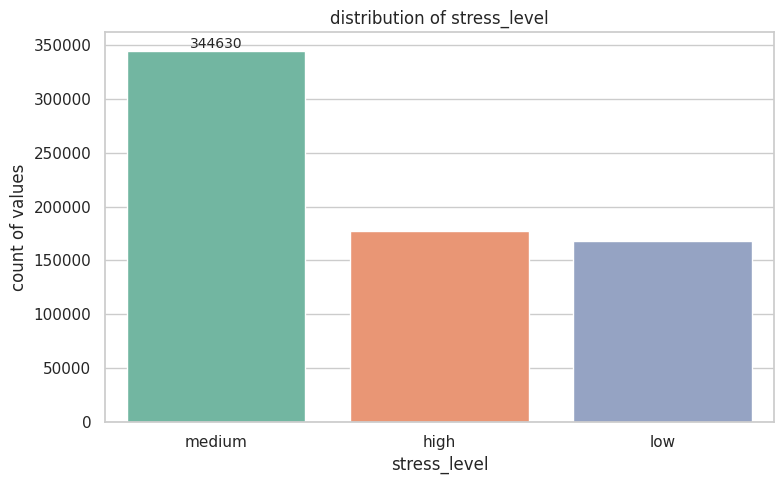

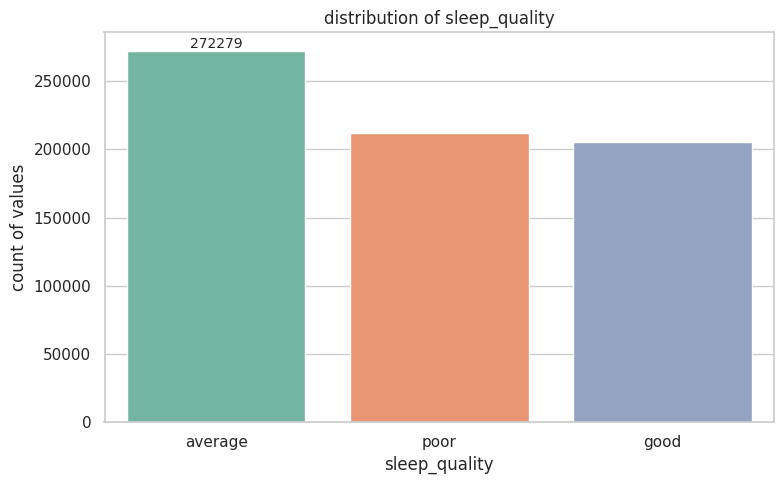

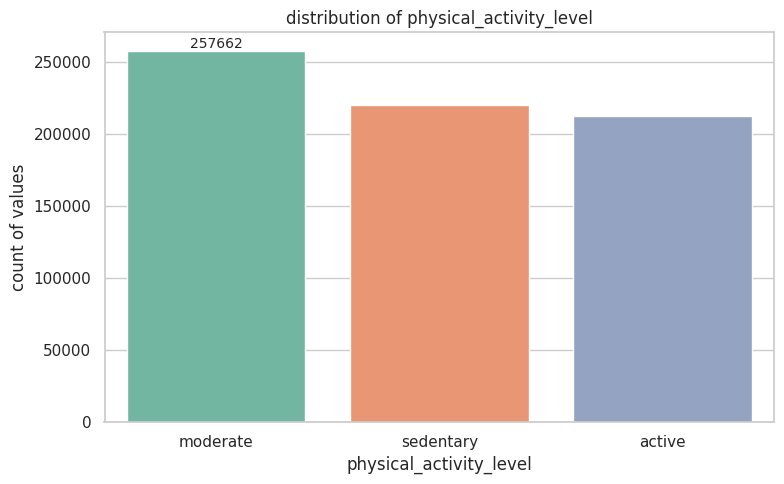

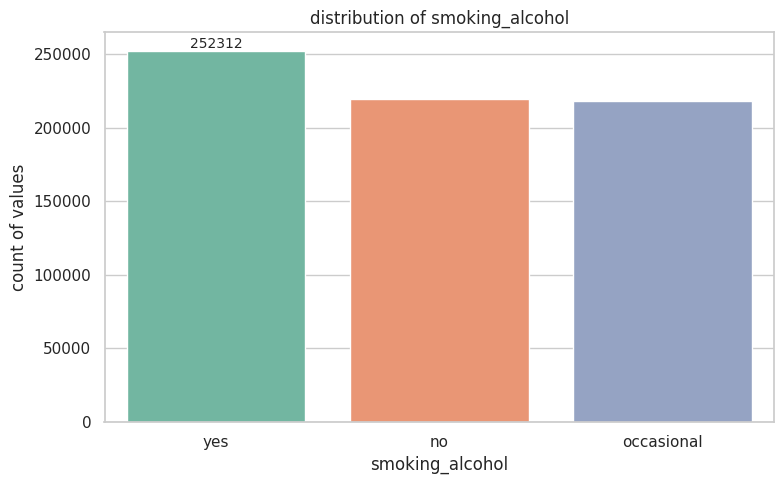

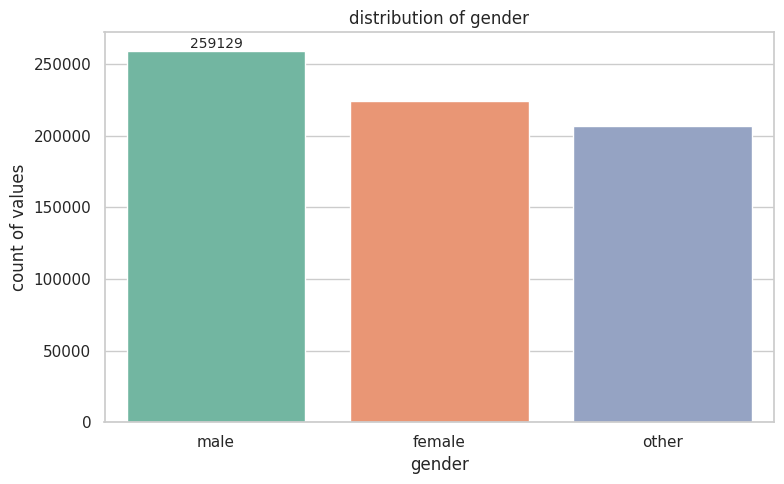

In [19]:
# Distribution of the categorical columns 
def categorical_chart(data,col):
    value=data[col].value_counts()
    plt.figure(figsize=(8,5))
    sns.set_theme(style='whitegrid')
    ax=sns. barplot(
        x=value.index,
        y=value.values,
        hue=value.index,
        palette='Set2',
    legend=False)
    ax.bar_label(ax.containers[0], fontsize=10)
    plt.title(f'distribution of {col}')
    plt.xlabel(f'{col}')
    plt.ylabel(f'count of values')
    plt.tight_layout()
    plt.show()
cat=data.select_dtypes(include='object').columns
for col in cat:
    categorical_chart(data,col)

# Machine Learning Modelling 
### First, we do Simple machine learning steps; if we get good accuracy, then we implement other techniques; otherwise, we go to other techniques.

In [20]:
# Import the machine learning libraries 
from sklearn.model_selection import train_test_split,cross_val_score,RepeatedStratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import accuracy_score,classification_report,balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# take just 1 lakh records for training purposes

data=data.head(100000)

# Label Encoder to convert the categorical columns; only use output
label=LabelEncoder()


# Let's drop the id columns and health condition and divide X,y
X=data.drop(['id', 'health_condition'], axis=1)
y=data['health_condition']

# Convert the categorical columns into numerical
encoder=OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1)
categorical=X.select_dtypes(include='object').columns
X[categorical]=encoder.fit_transform(X[categorical])
y=label.fit_transform(y)


#Split the data into train and test 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# Create a simple function for the machine learning model
def machine_Learning_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    model_pred=model.predict(X_test)
    print(f'\n {model.__class__} accuracy score is: {accuracy_score(y_test,model_pred):.2f}')
    print(f'\n  classification_report: {classification_report(y_test,model_pred)}')
    print(f'\n traing score accuracys : {model.score(X_train,y_train):.2f}')
    print(f'\n test score accuracy : {model.score(X_test,y_test)}')
    print(f'\n balance accuracy score:  {balanced_accuracy_score(y_test,model_pred):.2f}')
    cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
    score=cross_val_score(
        model, X,y,cv=cv,scoring='accuracy'
    )
    print(f'\n crooss_val_scire : {score.mean():.2f}')

In [ ]:
# apply the machine learning algorithm like Logistic and Random Forest 


dict_val={
    'logistic':LogisticRegression(),
    'random':RandomForestClassifier()
}
for val,key in dict_val.items():
     machine_Learning_model(key,X_train,X_test,y_train,y_test)


 <class 'sklearn.linear_model._logistic.LogisticRegression'> accuracy score is: 0.86

  classification_report:               precision    recall  f1-score   support

           0       0.86      1.00      0.93     17236
           1       0.10      0.00      0.01      1127
           2       0.00      0.00      0.00      1637

    accuracy                           0.86     20000
   macro avg       0.32      0.33      0.31     20000
weighted avg       0.75      0.86      0.80     20000


 traing score accuracys : 0.86

 test score accuracy : 0.8608

 balance accuracy score:  0.33

 crooss_val_scire : 0.86

 <class 'sklearn.ensemble._forest.RandomForestClassifier'> accuracy score is: 0.97

  classification_report:               precision    recall  f1-score   support

           0       0.97      1.00      0.98     17236
           1       0.95      0.78      0.85      1127
           2       0.98      0.77      0.86      1637

    accuracy                           0.97     20000
   m

# Another Technique
## Here is the problem I see: Because the dataset is imbalanced, we use imbalanced techniques to achieve a good, balanced score for output prediction.

In [ ]:
# Install the libraries for imbalanced techniques
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss


# Create dictionary to store all imbalanced techniques
samples={
    "original": None,
    'Randomundersampler': RandomUnderSampler(random_state=42),
    'Random Over sampler': RandomOverSampler(random_state=42),
    'smote': SMOTE(random_state=42),
    'Nearmiss': NearMiss()
}

# Create an empty dictionary to store the imbalanced library and the corresponding score
result ={}
for name, sampler in samples.items():
    if sampler is None:
        X_res,y_res=X_train,y_train
    else:
        X_res,y_res=sampler.fit_resample(X_train,y_train)
    # XGB Classifier model
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss"
    )
    # fit the model
    model.fit(X_res,y_res)
    # Prediction of the model
    model_pred=model.predict(X_test)
    score=balanced_accuracy_score(y_test,model_pred)
    result[name]=score
for sampler_name, sampler_score in result.items():
    print(f"{sampler_name}: {sampler_score:.4f}")

#### Based on the result, we will take the model with the best accuracy score that we tried with different algorithms.

In [ ]:
# We try with different algorithms like XGB, Random, VotingClassifier
from sklearn.ensemble import VotingClassifier

rf_model=RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss"
)
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft"
)

# Repeated the above techniques on the model
random_under=RandomUnderSampler(random_state=42)

# fit the random under sampler to the X and y, not to the x_train,y_train
X_train_random,y_train_random=random_under.fit_resample(X,y)

# Then fit with the model
ensemble.fit(X_train_random,y_train_random)

# Prediction of the model
xgb_model_pred=ensemble.predict(X_test)

# Checking the accuracy score and balanced accuracy score
balance_score=balanced_accuracy_score(y_test,xgb_model_pred)
accuracy=accuracy_score(y_test,xgb_model_pred)
print(f'balance accuracy score: {balance_score:.2f}')
print(f'accuracy_score : {accuracy:.2f}')

In [ ]:
# And finally apply our prediction to the test data 
test_categorical=test.select_dtypes(include='object').columns
# Convert the categorical to numerical 
test[test_categorical]=encoder.fit_transform(test[test_categorical])
# Prediction of the data
test_pred=ensemble.predict(test)
test_pred=label.inverse_transform(test_pred)
test_pred

### Finally submitted the overprediction 

In [ ]:
sub=pd.read_csv('/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv')
sub['health_condition']=test_pred
sub.to_csv('ensemble_1.csv',index=False)